In [1]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [2]:
# %%
SUBJECTS = helper_functions.get_subjects()

checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
]

# Latencies (seconds) per model
latencies = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.190],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.140, -0.08],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.35, -0.080],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.095],
}

colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

In [3]:
# %%
trf_data, n_subjects = helper_functions.load_trfs(checks)

# Compute grand mean TRFs
backward_trfs = {}
for predictor, attention, model, padded in checks:
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf_list   = [trf.h_scaled[0] if isinstance(trf.h_scaled, tuple) else trf.h_scaled 
                  for trf in trf_data[model_name]]
    backward_trfs[model_name] = eelbrain.combine(trf_list).mean('case')
    print(f"  ✓ Grand mean computed ({len(trf_list)} subjects)")

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18
Loaded TRFs for 18 subjects
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)


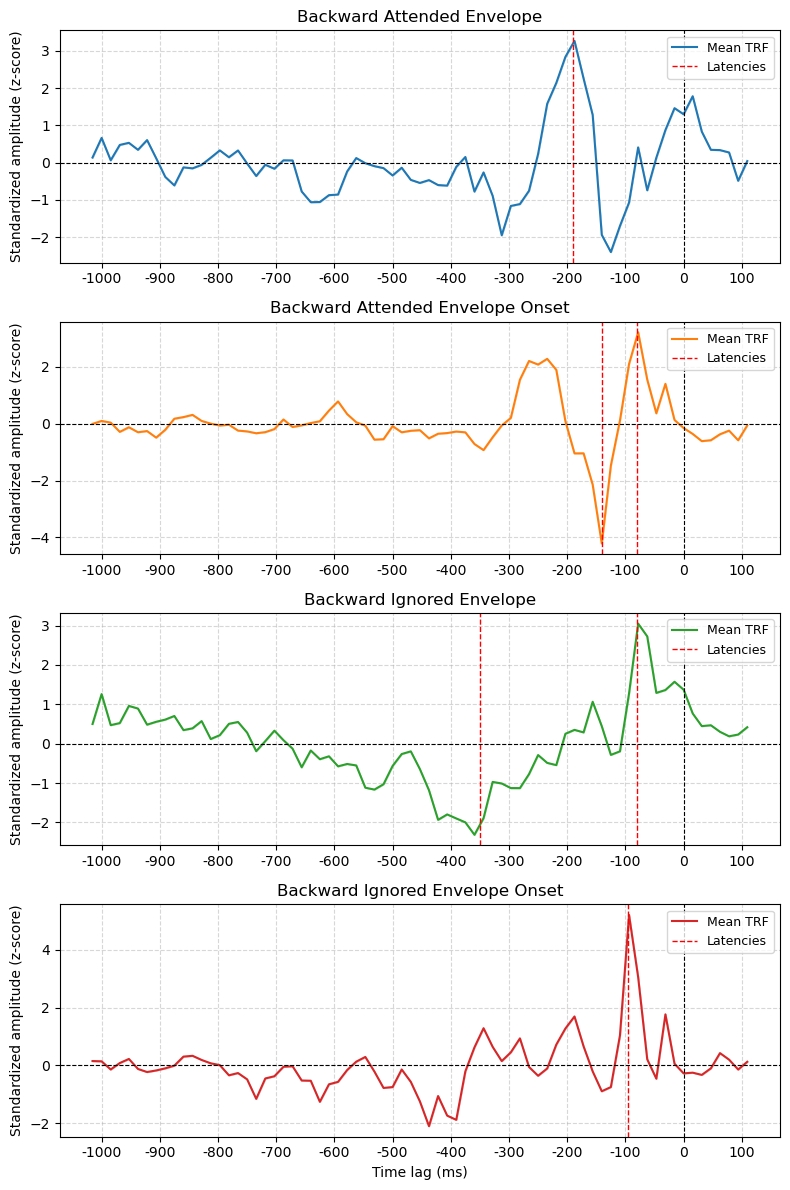

In [4]:
# %%
# Plot
fig, axes = plt.subplots(len(checks), 1, figsize=(8, 12), sharex=True)

for i, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf        = backward_trfs[model_name]

    trf_plot = trf.mean('sensor')
    trf_plot = trf_plot.mean('predictor') if 'predictor' in trf_plot.dims else trf_plot
    trf_std  = trf_plot.std('predictor')  if 'predictor' in trf_plot.dims else np.zeros_like(trf_plot.x)

    time_ms = np.array(trf_plot.time) * 1000
    y       = (trf_plot.x - np.mean(trf_plot.x)) / np.std(trf_plot.x)
    y_std   = np.array(trf_std) / np.std(trf_plot.x)

    axes[i].plot(time_ms, y, color=colors[model_name], label='Mean TRF')
    axes[i].fill_between(time_ms, y - y_std, y + y_std, color=colors[model_name], alpha=0.2)

    for j, t in enumerate(latencies[model_name]):
        axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1,
                        label='Latencies' if j == 0 else None)

    axes[i].set_title(model_name.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel('Standardized amplitude (z-score)')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].xaxis.set_major_locator(MultipleLocator(100))
    axes[i].xaxis.set_major_formatter(FormatStrFormatter('%d'))
    axes[i].tick_params(axis='x', labelbottom=True)

axes[-1].set_xlabel('Time lag (ms)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'decoder_trfs.pdf', bbox_inches='tight')
plt.show()